In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

In [ ]:
class State(TypedDict):
    counter: int
    status: str


In [ ]:
def propose_increment(state: State) -> dict:
    decision = interrupt(
        {
            "question": "Should we interrupt the counter?",
            "current_counter": state["counter"],
        }
    )

    if decision.get("approve"):
        return {
            "status": "approved",
            "counter": state["counter"]
        }
    else:
        return {"status": "rejected"}

def apply_increment(state: State) -> dict:
    return {
        "counter": state["counter"] + 1,
        "status": "incremented",
    }

In [ ]:
def route_after_propose(state: State) -> str:
    if state["status"] == "approved":
        return "apply_increment"
    else:
        return END


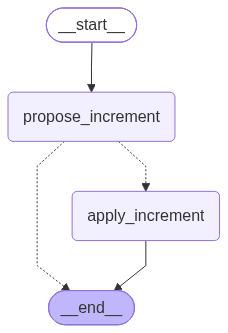

In [5]:
graph = StateGraph(State)

graph.add_node("propose_increment", propose_increment)
graph.add_node("apply_increment", apply_increment)

graph.add_edge(START, "propose_increment")
graph.add_conditional_edges(
    "propose_increment",
    route_after_propose,
    {
        "apply_increment": "apply_increment",
        END: END,
    }
)

graph.add_edge("apply_increment", END)

memory = MemorySaver()

app = graph.compile(checkpointer=memory)

app

In [ ]:
config = {"configurable": {"thread_id": "1"}}
initial_state = {"counter": 0, "status": "start"}

result = app.invoke(initial_state, config = config)

print(result)

print(result["__interrupt__"])

{'counter': 0, 'status': 'start', '__interrupt__': [Interrupt(value={'question': 'Should we interrupt the counter?', 'current_counter': 0}, id='a75fe42ee49cd3bcd1285d71249a2907')]}
[Interrupt(value={'question': 'Should we interrupt the counter?', 'current_counter': 0}, id='a75fe42ee49cd3bcd1285d71249a2907')]


In [ ]:
saved_state = app.get_state(config)
print(saved_state.values)
print("next nodes: ", saved_state.next)

{'counter': 0, 'status': 'start'}
next nodes:  ('propose_increment',)


In [ ]:
resume_value = {"approve": True}
command = Command(resume=resume_value)

result = app.invoke(command, config=config)
result

{'counter': 1, 'status': 'incremented'}

In [9]:
config2 = {"configurable": {"thread_id": "2"}}
initial_state2 = {"counter": 0, "status": "start"}

app.invoke(initial_state2, config=config2)
command2 = Command(resume={"approve": False})
result2 = app.invoke(command2, config=config2)

result2

{'counter': 0, 'status': 'rejected'}

In [ ]:
checkpoints = list(app.get_state_history(config))

for cp in checkpoints:
    print(f" Step {cp.metadata.get('step')}: {cp.values}")


 Step 2: {'counter': 1, 'status': 'incremented'}
 Step 1: {'counter': 0, 'status': 'approved'}
 Step 0: {'counter': 0, 'status': 'start'}
 Step -1: {}
